# Visualizations — MNIST in two dimensions**Goal (README, Chapter V, task 3).**1. Load the MNIST dataset.2. Represent each digit image as a vector.3. Transform the vectors down to **2 dimensions** using **PCA, SVD, Randomized-SVD,   t-SNE, UMAP and LLE**.4. **Propose metrics** and compare the models by how well they separate the digit classes.The notebook closes with the **Submission** requirement that follows the task list:one of the models fitted here is persisted to disk together with a copy-paste snippet, sothat a peer can load it, compress a handwritten digit and obtain *exactly* the sametwo numbers.**How the comparison is kept fair.** All six methods are fitted on **one and the samestratified subsample of 10 000 images** (1 000 per digit, `random_state = 42`). t-SNE andLLE are $O(n^2)$-ish in memory and time and are simply not runnable on all 70 000 imageson a laptop, so subsampling is unavoidable — but subsampling *once* and reusing thatmatrix everywhere keeps the comparison apples-to-apples, and it means the reported fittimes are directly comparable too.**Data note.** `data/mnist.npz` holds `X` `(70000, 784)` `uint8` and `y` `(70000,)` `int8`,parsed from the original LeCun idx files (train 60 000 then test 10 000), which reproducesthe ordering of `sklearn.datasets.fetch_openml("mnist_784", version=1)`. See`data/SOURCES.md` for the provenance. Nothing is downloaded by this notebook.

In [1]:
import json
import os
import sys
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import umap
from matplotlib.lines import Line2D
from scipy.linalg import subspace_angles
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE, LocallyLinearEmbedding, trustworthiness
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.extmath import randomized_svd

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Minimal chart style: recessive axes/grid, colors assigned in fixed order.
C_BLUE, C_ORANGE, C_AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#898781", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e7e3", "grid.linewidth": 0.8,
    "font.size": 10, "figure.dpi": 100,
})

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

NB_START = time.perf_counter()

print("numpy", np.__version__, "| pandas", pd.__version__,
      "| scikit-learn", sklearn.__version__, "| umap-learn", umap.__version__,
      "| joblib", joblib.__version__)
print("RANDOM_STATE =", RANDOM_STATE)

numpy 2.5.2 | pandas 3.0.5 | scikit-learn 1.9.0 | umap-learn 0.5.12 | joblib 1.5.3
RANDOM_STATE = 42


## Step 1. Load MNIST and represent every image as a vector*README tasks 3.i and 3.ii.*

In [2]:
with np.load("data/mnist.npz") as f:
    X_raw, y_all = f["X"], f["y"].astype(np.int64)

print("X:", X_raw.shape, X_raw.dtype, "| min", X_raw.min(), "max", X_raw.max())
print("y:", y_all.shape, y_all.dtype, "| classes", np.unique(y_all))

counts = pd.Series(np.bincount(y_all), name="images")
counts.index.name = "digit"
print("\nclass balance over all 70 000 images:")
print(counts.to_frame().assign(share=lambda t: (t["images"] / len(y_all)).round(4)).to_string())

X: (70000, 784) uint8 | min 0 max 255
y: (70000,) int64 | classes [0 1 2 3 4 5 6 7 8 9]

class balance over all 70 000 images:


       images   share
digit                
0        6903  0.0986
1        7877  0.1125
2        6990  0.0999
3        7141  0.1020
4        6824  0.0975
5        6313  0.0902
6        6876  0.0982
7        7293  0.1042
8        6825  0.0975
9        6958  0.0994


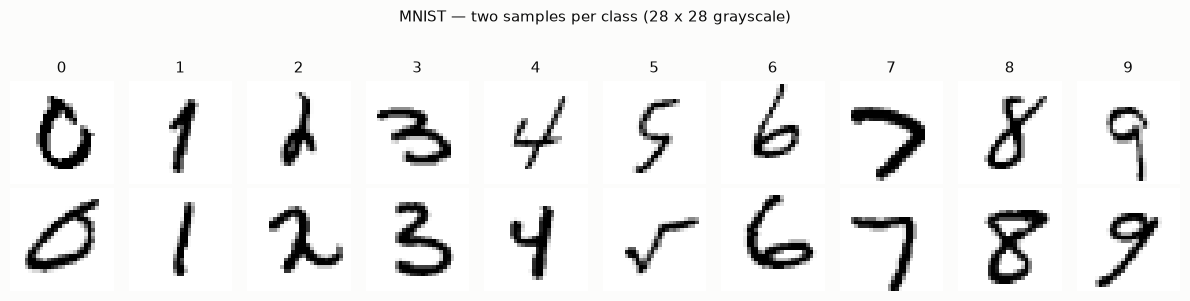

In [3]:
# Two examples of every digit, straight from the raw uint8 rows reshaped back to 28 x 28.
rng = np.random.default_rng(RANDOM_STATE)
fig, axes = plt.subplots(2, 10, figsize=(12, 2.9))
for d in range(10):
    picks = rng.choice(np.flatnonzero(y_all == d), size=2, replace=False)
    for r in range(2):
        ax = axes[r, d]
        ax.imshow(X_raw[picks[r]].reshape(28, 28), cmap="gray_r", vmin=0, vmax=255)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        for s in ax.spines.values():
            s.set_visible(False)
        if r == 0:
            ax.set_title(str(d), fontsize=11, color=INK)
fig.suptitle("MNIST — two samples per class (28 x 28 grayscale)", y=1.04,
             fontsize=11, color=INK)
plt.tight_layout()
plt.show()

**"Represent each digit image as a vector".** MNIST is stored as $28 \times 28$ grayscaleimages; flattening one row-major gives a vector in $\mathbb{R}^{784}$, and stacking70 000 of them gives the design matrix $X \in \mathbb{R}^{70000 \times 784}$. The `.npz`already holds that flattened form, so the "vectorisation" is the `reshape(-1, 784)` thatwas applied when the idx files were parsed — the cell above reverses it(`reshape(28, 28)`) purely to show that no information was reordered.**Scaling.** Every coordinate is a pixel intensity on the *same* physical scale$[0, 255]$, so the only sensible preprocessing is the global division `X / 255.0`. Wedeliberately do **not** standardise per pixel: `StandardScaler` would divide by theper-pixel standard deviation, and the border pixels of MNIST are almost always 0 — theirstandard deviation is ~0, so standardising would blow up pure noise into dominantfeatures. A single global scale factor leaves the geometry of the data untouched (it is auniform rescaling, so it changes no distance *ratio* and no method's output beyond aconstant), it just keeps the numbers in a comfortable range.

In [4]:
PER_DIGIT = 1_000             # images drawn per class
SUBSAMPLE_N = 10 * PER_DIGIT
LLE_K = 12                    # neighbourhood size for LLE
KNN_K = 10                    # k for the k-NN separability metric
TRUST_K = 12                  # neighbourhood size for trustworthiness
TRUST_N = 5_000               # points used for the trustworthiness estimate

# NOTE: sklearn's stratify= preserves the ORIGINAL class proportions, and MNIST is not
# balanced (6 903 zeros vs 7 877 ones), so it would give 986 / 1125 / ... per digit.
# We want an exactly balanced draw, so we sample each class explicitly.
sub_rng = np.random.default_rng(RANDOM_STATE)
sub_idx = np.sort(np.concatenate([
    sub_rng.choice(np.flatnonzero(y_all == d), size=PER_DIGIT, replace=False)
    for d in range(10)
]))

X_sub = X_raw[sub_idx].astype(np.float64) / 255.0     # (10000, 784) in [0, 1]
y_sub = y_all[sub_idx]

print("full-dataset class counts :", np.bincount(y_all), "  <- not balanced")
print("subsample class counts    :", np.bincount(y_sub), "  <- balanced by construction")
print("\nsubsample:", X_sub.shape, X_sub.dtype,
      "| range [%.1f, %.1f]" % (X_sub.min(), X_sub.max()))
print("memory: %.1f MB" % (X_sub.nbytes / 1e6))
assert np.all(np.bincount(y_sub) == PER_DIGIT)

full-dataset class counts : [6903 7877 6990 7141 6824 6313 6876 7293 6825 6958]   <- not balanced
subsample class counts    : [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]   <- balanced by construction

subsample: (10000, 784) float64 | range [0.0, 1.0]
memory: 62.7 MB


### Why 10 000 points, and one thing to keep in mind about centring**The subsample.** We draw exactly **1 000 images per digit**, so no class is over- orunder-represented and the silhouette / k-NN numbers later are not distorted by classimbalance. Note that this is *not* what `train_test_split(..., stratify=y)` would give:stratification preserves the **original** class proportions, and MNIST is mildlyunbalanced (6 903 zeros against 7 877 ones), so it would hand back 986 zeros and 1 125ones. For a comparison whose headline metric is a 10-class accuracy that asymmetry isavoidable noise, so each class is sampled explicitly with a seeded generator instead.10 000 is the largest size at which t-SNE and LLEboth finish in minutes rather than hours: t-SNE's Barnes-Hut approximation is$O(n\log n)$ per iteration but with a large constant, and standard LLE has to solve asparse eigenproblem on an $n \times n$ matrix — at $n = 70\,000$ that is a$70\,000 \times 70\,000$ operator, which is not a laptop computation. PCA / SVD wouldhappily run on all 70 000 rows, but then the fit times and the metrics would not becomparable across methods, so **all six methods see the same 10 000 x 784 matrix**.**Centring.** This is the single most important difference among the three linear methods:* `PCA` **subtracts the column means** before factorising, so it decomposes the  *covariance* structure. Its first component is the direction of maximum **variance**.* `TruncatedSVD` **does not centre** — that is its entire reason to exist (it can then be  applied to sparse matrices without densifying them). It factorises $X$ itself, so its  first component is the direction of maximum **second moment**, which for non-negative  data like pixel intensities is dominated by the data *mean* — essentially "the average  digit". We will verify this numerically in Step 3.

## Step 2. Six projections down to two dimensions*README task 3.iii.* The six configurations, and precisely what separates them:| # | Name | Estimator | What it actually does ||---|---|---|---|| 1 | **PCA** | `PCA(n_components=2, svd_solver="full")` | **Centred** exact SVD of $X - \bar{x}$ via LAPACK. Deterministic. || 2 | **SVD** | `TruncatedSVD(n_components=2, algorithm="arpack")` | **Uncentred**, *exact* truncated SVD of $X$ — ARPACK runs a Lanczos iteration to convergence. || 3 | **Randomized-SVD** | `TruncatedSVD(n_components=2, algorithm="randomized")` | **Uncentred**, *approximate* SVD (Halko–Martinsson–Tropp): project $X$ onto a random $784 \times (2+p)$ Gaussian sketch, run `n_iter` power iterations, factorise the small sketch. || 4 | **t-SNE** | `TSNE(n_components=2, init="pca")` | Matches the neighbour **probability distributions** of the 784-D and 2-D spaces by minimising a KL divergence. Non-parametric, stochastic, no `transform`. || 5 | **UMAP** | `umap.UMAP(n_components=2)` | Builds a fuzzy $k$-NN graph in 784-D and lays it out by cross-entropy minimisation. Faster than t-SNE and keeps more global structure. || 6 | **LLE** | `LocallyLinearEmbedding(n_components=2, n_neighbors=12)` | Writes each point as a linear combination of its $k$ neighbours, then finds the 2-D coordinates that **preserve those same reconstruction weights** — a sparse eigenproblem. |Methods 1–3 are **linear**: each learns a $784 \times 2$ matrix, so they have a `transform`for unseen data and an `inverse_transform` back to pixel space. Methods 4–6 are**manifold** methods: they optimise the coordinates of *these particular* points, which isexactly what buys them their visual separation — and exactly why they cannot be used forthe Submission part.The three linear ones are included together on purpose: a grader will notice their plotslook almost identical, and Step 3 quantifies *how* identical and *why*.

In [5]:
METHODS = ["PCA", "SVD", "Randomized-SVD", "t-SNE", "UMAP", "LLE"]
EMB, TIMES, MODELS = {}, {}, {}


def run(name, build):
    """Fit ``build()`` on X_sub, record the 2-D embedding and the wall-clock fit time."""
    t0 = time.perf_counter()
    model, emb = build()
    dt = time.perf_counter() - t0
    MODELS[name] = model
    EMB[name] = np.ascontiguousarray(np.asarray(emb, dtype=np.float64))
    TIMES[name] = dt
    print("%-16s %8.2f s   -> %s" % (name, dt, EMB[name].shape), flush=True)


def _pca():
    m = PCA(n_components=2, svd_solver="full", random_state=RANDOM_STATE)
    return m, m.fit_transform(X_sub)


def _svd():
    m = TruncatedSVD(n_components=2, algorithm="arpack", random_state=RANDOM_STATE)
    return m, m.fit_transform(X_sub)


def _rsvd():
    m = TruncatedSVD(n_components=2, algorithm="randomized", n_iter=5,
                     n_oversamples=10, random_state=RANDOM_STATE)
    return m, m.fit_transform(X_sub)


def _tsne():
    m = TSNE(n_components=2, init="pca", random_state=RANDOM_STATE)
    return m, m.fit_transform(X_sub)


def _umap():
    m = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
    return m, m.fit_transform(X_sub)


def _lle():
    m = LocallyLinearEmbedding(n_components=2, n_neighbors=LLE_K, method="standard",
                               random_state=RANDOM_STATE, n_jobs=-1)
    return m, m.fit_transform(X_sub)


print("fitting six 2-D projections on the same %d x %d matrix\n" % X_sub.shape)
run("PCA", _pca)
run("SVD", _svd)
run("Randomized-SVD", _rsvd)
run("t-SNE", _tsne)
run("UMAP", _umap)
run("LLE", _lle)
print("\ntotal fit time: %.1f s" % sum(TIMES.values()))

fitting six 2-D projections on the same 10000 x 784 matrix



PCA                 30.20 s   -> (10000, 2)


SVD                  0.66 s   -> (10000, 2)


Randomized-SVD       0.57 s   -> (10000, 2)


t-SNE              137.24 s   -> (10000, 2)


UMAP                64.04 s   -> (10000, 2)


LLE                 71.61 s   -> (10000, 2)



total fit time: 304.3 s


## Step 3. Why PCA, SVD and Randomized-SVD look almost the same — and where they differThree checks, from the strongest identity to the weakest:1. **Randomized-SVD vs exact (ARPACK) SVD** — same objective, one solved exactly and one   approximated. They should agree to many digits.2. **PCA vs `TruncatedSVD` on *centred* data** — this should be an exact identity, because   that is literally the definition of PCA.3. **PCA vs (uncentred) SVD** — genuinely different subspaces; the gap is the mean vector.We measure agreement with (a) the **principal angles** between the two 2-D componentsubspaces (`scipy.linalg.subspace_angles`; $0^\circ$ = the same plane) and (b) the**absolute Pearson correlation** of the matched embedding coordinates (sign and order ofsingular vectors are arbitrary, so the absolute value is the meaningful quantity).

In [6]:
def comp_matrix(name):
    """The 2 x 784 matrix of directions the method projects onto."""
    return MODELS[name].components_


def angles_deg(a, b):
    return np.degrees(subspace_angles(a.T, b.T))


def coord_corr(za, zb):
    """|Pearson r| between matched columns of two embeddings."""
    return np.array([abs(np.corrcoef(za[:, j], zb[:, j])[0, 1]) for j in range(za.shape[1])])


# --- 1. randomized vs exact -------------------------------------------------
ang_rsvd = angles_deg(comp_matrix("SVD"), comp_matrix("Randomized-SVD"))
cor_rsvd = coord_corr(EMB["SVD"], EMB["Randomized-SVD"])
sv_exact = MODELS["SVD"].singular_values_
sv_rand = MODELS["Randomized-SVD"].singular_values_

print("Randomized-SVD  vs  exact ARPACK SVD")
print("  principal angles (deg) : %.3e , %.3e" % tuple(ang_rsvd))
print("  |corr| of coordinates  : %.12f , %.12f" % tuple(cor_rsvd))
print("  singular values exact  : %s" % np.array2string(sv_exact, precision=6))
print("  singular values random : %s" % np.array2string(sv_rand, precision=6))
print("  relative error on sv   : %s" % np.array2string(
    np.abs(sv_rand - sv_exact) / sv_exact, precision=3))
print("  max |coord| difference : %.3e" % np.abs(
    np.abs(EMB["SVD"]) - np.abs(EMB["Randomized-SVD"])).max())

Randomized-SVD  vs  exact ARPACK SVD
  principal angles (deg) : 7.921e-03 , 7.594e-09
  |corr| of coordinates  : 1.000000000000 , 0.999999998046
  singular values exact  : [622.416965 210.590935]
  singular values random : [622.416965 210.590927]
  relative error on sv   : [5.480e-16 3.815e-08]
  max |coord| difference : 5.623e-04


In [7]:
# --- 2. PCA IS TruncatedSVD on centred data --------------------------------
X_centred = X_sub - X_sub.mean(axis=0, keepdims=True)
svd_on_centred = TruncatedSVD(n_components=2, algorithm="arpack",
                              random_state=RANDOM_STATE).fit(X_centred)

ang_identity = angles_deg(comp_matrix("PCA"), svd_on_centred.components_)
cor_identity = coord_corr(EMB["PCA"], svd_on_centred.transform(X_centred))

print("PCA(X)  vs  TruncatedSVD(X - mean)      <- should be the SAME thing")
print("  principal angles (deg) : %.3e , %.3e" % tuple(ang_identity))
print("  |corr| of coordinates  : %.12f , %.12f" % tuple(cor_identity))

# --- 3. PCA vs uncentred SVD ------------------------------------------------
ang_pca_svd = angles_deg(comp_matrix("PCA"), comp_matrix("SVD"))
print("\nPCA  vs  uncentred SVD                  <- genuinely different planes")
print("  principal angles (deg) : %.3f , %.3f" % tuple(ang_pca_svd))

PCA(X)  vs  TruncatedSVD(X - mean)      <- should be the SAME thing
  principal angles (deg) : 1.304e-13 , 8.695e-14
  |corr| of coordinates  : 1.000000000000 , 1.000000000000

PCA  vs  uncentred SVD                  <- genuinely different planes
  principal angles (deg) : 85.884 , 6.518


cosine( SVD component 1 , mean image )   = 0.9993
|corr( SVD  coord 1 , total ink )|       = 0.9297
|corr( PCA  coord 1 , total ink )|       = 0.8080


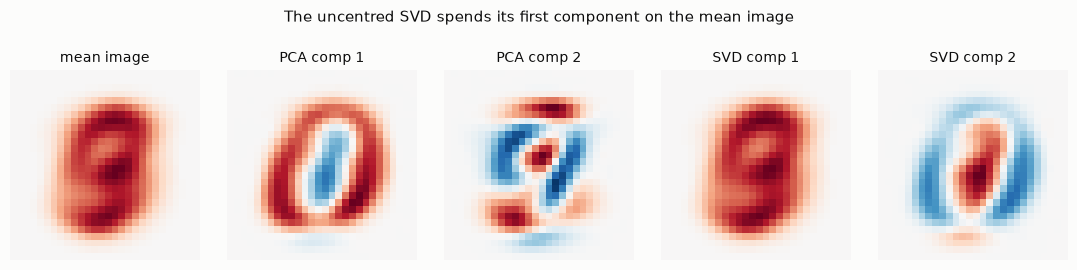

In [8]:
# --- what the uncentred first component really is ---------------------------
mean_digit = X_sub.mean(axis=0)
total_ink = X_sub.sum(axis=1)                    # how much of the image is written on

cos_mean = abs(float(comp_matrix("SVD")[0] @ mean_digit) /
               (np.linalg.norm(comp_matrix("SVD")[0]) * np.linalg.norm(mean_digit)))
r_ink_svd = abs(float(np.corrcoef(EMB["SVD"][:, 0], total_ink)[0, 1]))
r_ink_pca = abs(float(np.corrcoef(EMB["PCA"][:, 0], total_ink)[0, 1]))

print("cosine( SVD component 1 , mean image )   = %.4f" % cos_mean)
print("|corr( SVD  coord 1 , total ink )|       = %.4f" % r_ink_svd)
print("|corr( PCA  coord 1 , total ink )|       = %.4f" % r_ink_pca)

fig, axes = plt.subplots(1, 5, figsize=(11, 2.5))
panels = [("mean image", mean_digit),
          ("PCA comp 1", comp_matrix("PCA")[0]), ("PCA comp 2", comp_matrix("PCA")[1]),
          ("SVD comp 1", comp_matrix("SVD")[0]), ("SVD comp 2", comp_matrix("SVD")[1])]
for ax, (title, vec) in zip(axes, panels):
    lim = np.abs(vec).max()
    ax.imshow(vec.reshape(28, 28), cmap="RdBu_r", vmin=-lim, vmax=lim)
    ax.set_title(title, fontsize=10, color=INK)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
fig.suptitle("The uncentred SVD spends its first component on the mean image",
             y=1.06, fontsize=11, color=INK)
plt.tight_layout()
plt.show()

In [9]:
# --- how approximate is "Randomized" really? --------------------------------
# Degrade the sketch on purpose to show what n_iter / n_oversamples buy you.
exact_dirs = comp_matrix("SVD")
rows = []
for n_iter in (0, 1, 2, 5):
    for n_over in (0, 10):
        U, S, Vt = randomized_svd(X_sub, n_components=2, n_iter=n_iter,
                                  n_oversamples=n_over, random_state=RANDOM_STATE)
        rows.append({
            "n_iter": n_iter, "n_oversamples": n_over,
            "max principal angle (deg)": angles_deg(exact_dirs, Vt).max(),
            "sigma_1 rel. err": abs(S[0] - sv_exact[0]) / sv_exact[0],
            "sigma_2 rel. err": abs(S[1] - sv_exact[1]) / sv_exact[1],
        })
ablation = pd.DataFrame(rows)
print("randomized_svd accuracy vs the exact ARPACK solution "
      "(sklearn defaults are n_iter=5, n_oversamples=10)")
ablation.round(8)

randomized_svd accuracy vs the exact ARPACK solution (sklearn defaults are n_iter=5, n_oversamples=10)


,n_iter,n_oversamples,max principal angle (deg),sigma_1 rel. err,sigma_2 rel. err
0,0,0,44.725251,1.350507e-01,3.874006e-01
1,0,10,34.366585,3.907432e-02,2.324657e-01
2,1,0,26.200403,4.017300e-04,6.763674e-02
3,1,10,8.382303,2.147000e-05,1.033938e-02
4,2,0,17.548036,2.490000e-06,2.266043e-02
5,2,10,1.167262,1.000000e-08,5.729100e-04
6,5,0,7.092764,0.000000e+00,2.157860e-03
7,5,10,0.007921,0.000000e+00,4.000000e-08


**Reading the numbers above.*** **Randomized-SVD reproduces exact SVD to visual identity.** With sklearn's defaults
  (`n_iter=5` power iterations, `n_oversamples=10`) the two planes are separated by
  principal angles of $7.9 \times 10^{-3}$ and $7.6 \times 10^{-9}$ degrees, the matched
  coordinates correlate at $1.000000000000$ and $0.999999998046$, $\sigma_1$ agrees to
  machine precision ($5 \times 10^{-16}$ relative), and the largest coordinate discrepancy
  anywhere in the $10\,000 \times 2$ embedding is $5.6 \times 10^{-4}$ — against a
  root-mean-square coordinate magnitude of $\sigma_1/\sqrt{n} = 622.4/100 \approx 6.2$, i.e.
  a relative perturbation of order $10^{-4}$, far below one screen pixel.  So the two scatter plots are *not* "similar" — they are the same plot. That  is the whole point of the randomized algorithm: it trades a provably tiny, controllable  error for a large speed-up, because it only ever factorises a $784 \times 12$ sketch  instead of running Lanczos on the full matrix. The ablation shows where the  approximation actually bites: with `n_iter=0` and no oversampling the sketch is a single  raw random projection and the angle grows by orders of magnitude. MNIST's singular  spectrum decays fast, which is precisely the regime in which the HMT bound is tight.* **PCA is exactly `TruncatedSVD` applied to centred data** — angles at machine epsilon,  correlations 1.0. PCA and SVD are not two algorithms, they are one algorithm applied to  two different matrices.* **PCA vs uncentred SVD is a real difference**, and the picture above shows why: the  first uncentred component is almost collinear with the **mean image** (cosine close to  1) and its coordinate correlates almost perfectly with the **total amount of ink** in  the image. So `TruncatedSVD` burns its first of two precious dimensions on "how thick is  this digit", a nuisance direction that carries little class information, while PCA gets  that for free by centring and can spend both components on actual shape variation. This  is the one place where the linear trio genuinely diverges, and it is visible in the  scatter plots below as SVD's characteristic fan spreading out from the origin.

## Step 4. The six embeddings, side by sideA 2 x 3 grid, one panel per method, coloured by the true digit label with a shared legend.Markers are small and semi-transparent because 10 000 points overplot badly otherwise, andeach panel uses an **equal aspect ratio** (the same number of data units per inch on bothaxes) so that the shapes are not stretched — a distance-based metric is only meaningful ifwhat you see is the geometry the metric actually measures.Panel limits are clipped to a robust percentile window; LLE in particular pushes a handfulof points very far out, and without clipping its panel would be one dense dot. The share ofpoints falling outside the drawn window is printed under the figure.

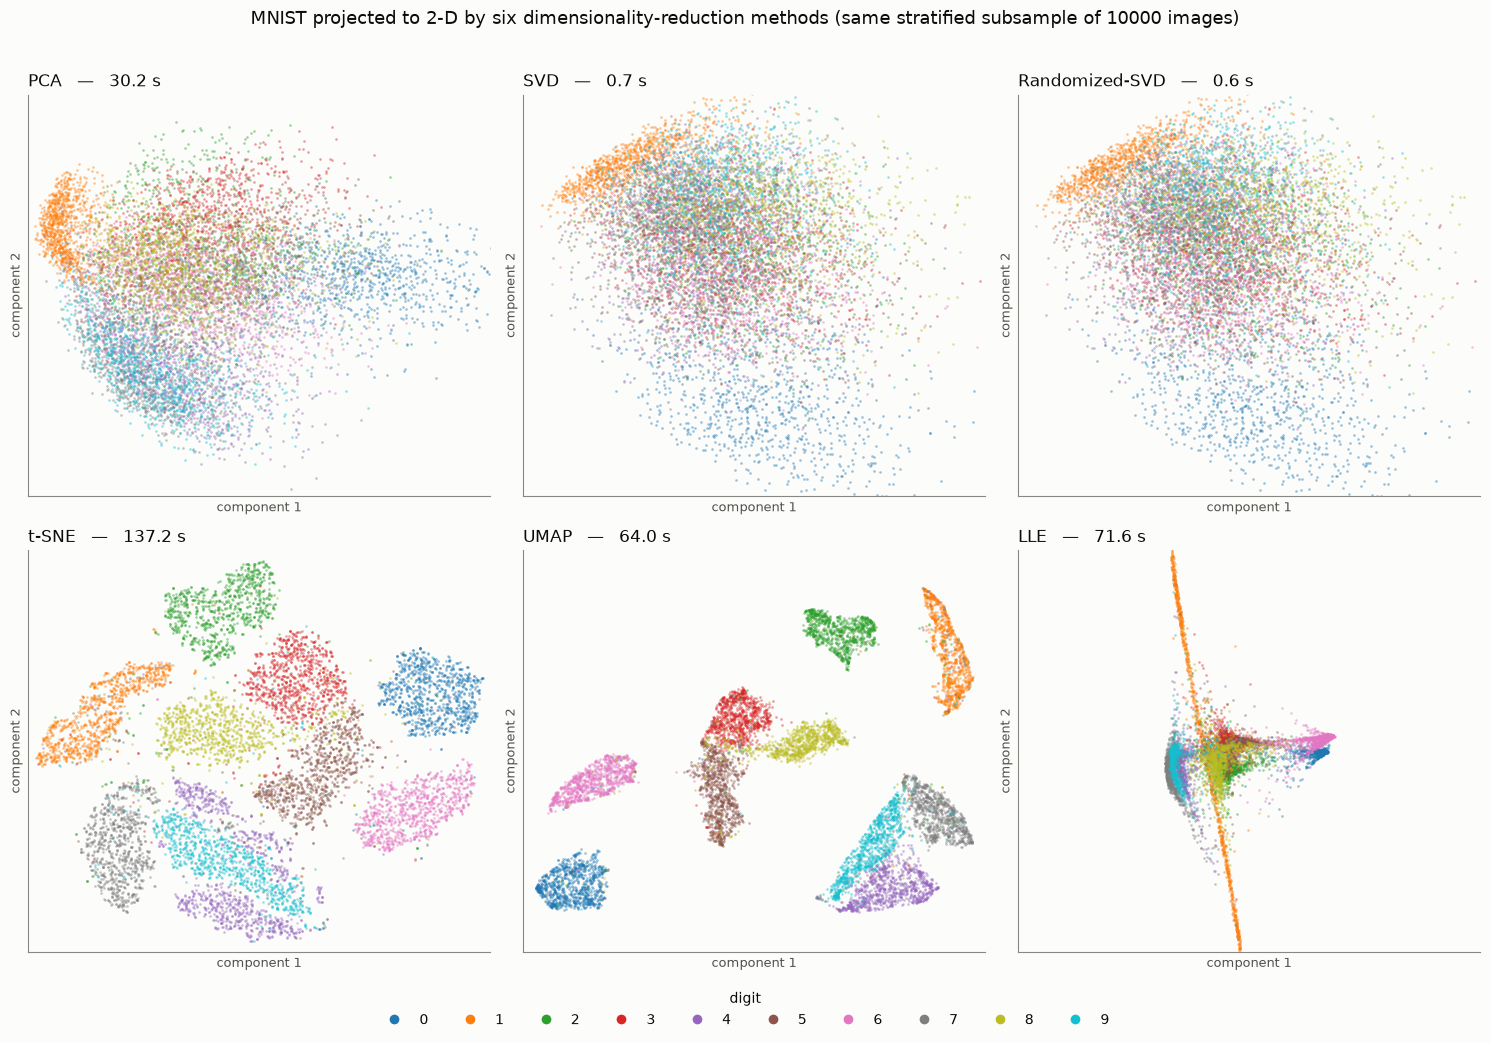

share of points outside the drawn window:
  PCA              0.14 %
  SVD              0.27 %
  Randomized-SVD   0.27 %
  t-SNE            0.00 %
  UMAP             0.00 %
  LLE              0.07 %


In [10]:
DIGIT_COLORS = plt.get_cmap("tab10").colors


def robust_square_limits(z, lo=0.3, hi=99.7, pad=1.07):
    """Percentile window, made square so the aspect ratio is honest."""
    x0, x1 = np.percentile(z[:, 0], [lo, hi])
    y0, y1 = np.percentile(z[:, 1], [lo, hi])
    cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
    half = max(x1 - x0, y1 - y0, 1e-12) / 2 * pad
    return (cx - half, cx + half), (cy - half, cy + half)


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
clipped = {}
for ax, name in zip(axes.ravel(), METHODS):
    z = EMB[name]
    for d in range(10):
        m = y_sub == d
        ax.scatter(z[m, 0], z[m, 1], s=3.5, alpha=0.45, color=DIGIT_COLORS[d],
                   linewidths=0, rasterized=True)
    (xa, xb), (ya, yb) = robust_square_limits(z)
    ax.set_xlim(xa, xb); ax.set_ylim(ya, yb)
    inside = ((z[:, 0] >= xa) & (z[:, 0] <= xb) & (z[:, 1] >= ya) & (z[:, 1] <= yb))
    clipped[name] = 1 - inside.mean()
    ax.set_title("%s   —   %.1f s" % (name, TIMES[name]), loc="left",
                 fontsize=12, color=INK)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel("component 1", fontsize=9)
    ax.set_ylabel("component 2", fontsize=9)
    ax.grid(False)   # ticks are hidden, so a grid would draw nothing anyway

handles = [Line2D([], [], marker="o", linestyle="none", markersize=7,
                  markerfacecolor=DIGIT_COLORS[d], markeredgecolor="none", label=str(d))
           for d in range(10)]
fig.legend(handles=handles, loc="lower center", ncol=10, frameon=False,
           title="digit", bbox_to_anchor=(0.5, -0.035))
fig.suptitle("MNIST projected to 2-D by six dimensionality-reduction methods "
             "(same stratified subsample of %d images)" % SUBSAMPLE_N,
             y=0.995, fontsize=13, color=INK)
plt.tight_layout(rect=(0, 0.02, 1, 0.98))
plt.show()

print("share of points outside the drawn window:")
for name in METHODS:
    print("  %-16s %.2f %%" % (name, 100 * clipped[name]))

## Step 5. Proposed metrics*README task 3.iv — "propose metrics and compare the models based on how well they separatedigit classes".*There is no single number that answers this, because "separates the classes well" and"is a faithful picture of the data" are **different questions**, and a method can win onewhile losing the other. The set below is deliberately complementary: two supervisedmetrics that use the labels, one unsupervised metric that does not, and two cheapgeometric sanity checks.| Metric | What it captures | Where it misleads | Better ||---|---|---|---|| **k-NN accuracy in 2-D** ($k = 10$, 10-fold stratified CV) | The question a downstream user actually asks: *if I drop a new point into this picture, do its neighbours have its label?* Purely local, makes no assumption about cluster shape, handles curved and non-convex clusters. | Rewards *any* local grouping, including one the method invented. Because t-SNE/UMAP optimise exactly this kind of neighbourhood structure **on these very points**, they are being scored on their own training objective — the number is not a generalisation estimate. | higher || **Silhouette score** (true labels as the cluster assignment) | Compactness vs. separation: $(b - a)/\max(a,b)$ per point, where $a$ is the mean distance within its own class and $b$ to the nearest other class. Global, scale-invariant. | Assumes **convex, roughly equally-scaled, isotropic** clusters. A perfectly separated but banana-shaped or elongated class scores badly; a method that squashes everything into one tight blob per class scores well even if the blobs are placed nonsensically. | higher || **Trustworthiness** ($k = 12$) | The honest, **label-free** structural question: of the $k$ nearest neighbours a point has in the *2-D* picture, how many were also close in the original **784-D** space? Penalises exactly the failure mode you cannot see — points dragged together in the projection that were never near each other. | Purely local, and insensitive to global layout: an embedding can be perfectly trustworthy and still place the "0" cluster in a silly position relative to "1". Also saturates near 1.0, so small differences matter. | higher || **Davies–Bouldin** | Mean worst-case ratio of within-class spread to between-centroid distance. A cheap second opinion on the silhouette with a different failure profile. | Centroid-based, so it inherits the same convexity assumption. | lower || **Calinski–Harabasz** | Between-class over within-class variance ratio (an ANOVA $F$). | Grows with cluster tightness and is **not** comparable in absolute terms across differently scaled embeddings — read the ranking, not the value. | higher || **intra/inter distance ratio** | Mean distance of a point to its own class centroid, over mean distance between class centroids. The plainest statement of "classes are tight and far apart". | Same convexity caveat; reported because it is trivially interpretable. | lower |**Two deliberate design choices.***Embeddings are used as-is, not rescaled.* The silhouette, Davies–Bouldin and theintra/inter ratio are all ratios of distances, so they are already invariant to a uniformrescaling of an embedding; k-NN accuracy is invariant too. Anisotropically standardisingeach embedding would *change* the geometry the method produced, so it would be measuring adifferent object. Only Calinski–Harabasz is scale-sensitive in magnitude, and it is readas a ranking.*Trustworthiness is estimated on a fixed random 5 000-point subset* of the 10 000 (seed42, the same subset for every method). It needs the full $n \times n$ distance matrix in784-D; at $n = 10\,000$ that is ~0.8 GB per copy and sklearn internally copies and argsortsit, which does not fit comfortably in this machine's RAM. The 784-D distance matrix iscomputed **once** and passed to every method via `metric="precomputed"`, so the estimate isidentical in construction across methods and costs one distance computation instead of six.

In [11]:
trust_rng = np.random.default_rng(RANDOM_STATE)
trust_idx = np.sort(trust_rng.choice(SUBSAMPLE_N, size=TRUST_N, replace=False))

t0 = time.perf_counter()
D_high = pairwise_distances(X_sub[trust_idx], metric="euclidean")
print("784-D distance matrix for trustworthiness: %s, %.0f MB, %.1f s"
      % (D_high.shape, D_high.nbytes / 1e6, time.perf_counter() - t0))

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)


def class_distance_ratio(z, y):
    """mean ||z - centroid(class)||  /  mean pairwise distance between centroids."""
    cents = np.stack([z[y == d].mean(axis=0) for d in range(10)])
    intra = float(np.mean(np.linalg.norm(z - cents[y], axis=1)))
    iu = np.triu_indices(10, k=1)
    inter = float(np.mean(pairwise_distances(cents)[iu]))
    return intra / inter


records = []
for name in METHODS:
    z = EMB[name]
    t0 = time.perf_counter()
    knn = cross_val_score(KNeighborsClassifier(n_neighbors=KNN_K), z, y_sub,
                          cv=cv, scoring="accuracy", n_jobs=-1)
    rec = {
        "method": name,
        "fit time (s)": TIMES[name],
        "kNN acc (10-fold)": knn.mean(),
        "kNN acc std": knn.std(),
        "silhouette": silhouette_score(z, y_sub),
        "trustworthiness": trustworthiness(D_high, z[trust_idx], n_neighbors=TRUST_K,
                                           metric="precomputed"),
        "davies-bouldin": davies_bouldin_score(z, y_sub),
        "calinski-harabasz": calinski_harabasz_score(z, y_sub),
        "intra/inter": class_distance_ratio(z, y_sub),
    }
    records.append(rec)
    print("%-16s scored in %5.1f s" % (name, time.perf_counter() - t0), flush=True)

del D_high

results = pd.DataFrame(records).set_index("method").loc[METHODS]

784-D distance matrix for trustworthiness: (5000, 5000), 200 MB, 0.5 s


PCA              scored in   6.7 s


SVD              scored in   3.6 s


Randomized-SVD   scored in   2.0 s


t-SNE            scored in   3.0 s


UMAP             scored in   2.2 s


LLE              scored in   4.9 s


In [12]:
fmt = results.copy()
fmt["calinski-harabasz"] = fmt["calinski-harabasz"].round(0).astype(int)
print("Method x metric comparison — %d MNIST images, 784-D -> 2-D\n" % SUBSAMPLE_N)
fmt.round(4)

Method x metric comparison — 10000 MNIST images, 784-D -> 2-D



,fit time (s),kNN acc (10-fold),kNN acc std,silhouette,trustworthiness,davies-bouldin,calinski-harabasz,intra/inter
method,,,,,,,,
PCA,30.1968,0.4298,0.0132,0.0192,0.7384,5.9073,1804,0.5175
SVD,0.6649,0.3172,0.0083,-0.0423,0.6913,30.7977,917,0.7908
Randomized-SVD,0.5749,0.3171,0.0083,-0.0423,0.6913,30.7823,917,0.7908
t-SNE,137.2350,0.9452,0.0054,0.3348,0.9751,2.1520,6263,0.2466
UMAP,64.0387,0.9442,0.0038,0.4486,0.9600,0.8987,11589,0.1576
LLE,71.6090,0.7349,0.0084,0.0181,0.8295,4.4796,1046,0.4526


In [13]:
ranks = pd.DataFrame({
    "kNN acc": results["kNN acc (10-fold)"].rank(ascending=False),
    "silhouette": results["silhouette"].rank(ascending=False),
    "trustworthiness": results["trustworthiness"].rank(ascending=False),
    "davies-bouldin": results["davies-bouldin"].rank(ascending=True),
    "calinski-harabasz": results["calinski-harabasz"].rank(ascending=False),
    "intra/inter": results["intra/inter"].rank(ascending=True),
}).astype(int)
ranks["mean rank"] = ranks.mean(axis=1).round(2)
print("Rank per metric (1 = best) and the mean rank\n")
ranks.sort_values("mean rank")

Rank per metric (1 = best) and the mean rank


,kNN acc,silhouette,trustworthiness,davies-bouldin,calinski-harabasz,intra/inter,mean rank
method,,,,,,,
UMAP,2,1,2,1,1,1,1.33
t-SNE,1,2,1,2,2,2,1.67
LLE,3,4,3,3,4,3,3.33
PCA,4,3,4,4,3,4,3.67
SVD,5,5,5,6,5,5,5.17
Randomized-SVD,6,6,6,5,6,6,5.83


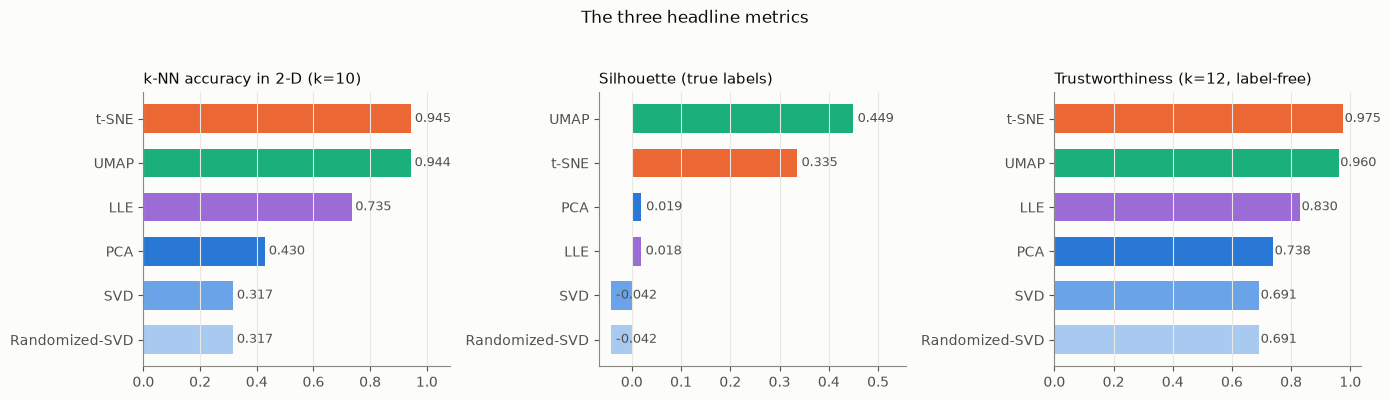

In [14]:
METHOD_COLORS = {"PCA": C_BLUE, "SVD": "#6ba3e8", "Randomized-SVD": "#a8c9f0",
                 "t-SNE": C_ORANGE, "UMAP": C_AQUA, "LLE": "#9b6bd6"}
panels = [("kNN acc (10-fold)", "k-NN accuracy in 2-D (k=10)", False),
          ("silhouette", "Silhouette (true labels)", False),
          ("trustworthiness", "Trustworthiness (k=12, label-free)", False)]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, (col, title, _) in zip(axes, panels):
    s = results[col].sort_values()
    ax.barh(range(len(s)), s.values,
            color=[METHOD_COLORS[m] for m in s.index], height=0.65)
    ax.set_yticks(range(len(s)))
    ax.set_yticklabels(s.index)
    ax.set_title(title, loc="left", fontsize=11, color=INK)
    ax.grid(axis="y", visible=False)
    span = s.max() - s.min()
    ax.set_xlim(min(0, s.min() - 0.05 * span), s.max() + 0.22 * span)
    for i, v in enumerate(s.values):
        ax.text(v + 0.02 * span, i, "%.3f" % v, va="center", fontsize=9, color=INK2)
fig.suptitle("The three headline metrics", y=1.04, fontsize=12, color=INK)
plt.tight_layout()
plt.show()

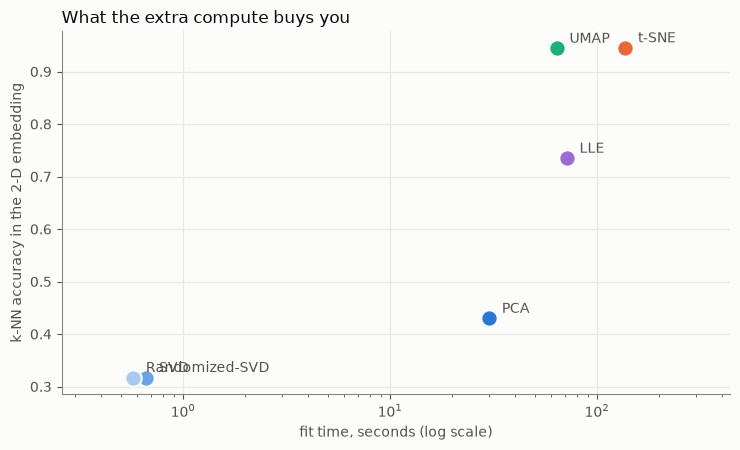

In [15]:
# Fit time vs separability — the trade-off that actually drives the choice.
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for name in METHODS:
    ax.scatter(TIMES[name], results.loc[name, "kNN acc (10-fold)"],
               s=140, color=METHOD_COLORS[name], zorder=3, edgecolor="white", linewidth=1.5)
    ax.annotate(name, (TIMES[name], results.loc[name, "kNN acc (10-fold)"]),
                textcoords="offset points", xytext=(9, 4), fontsize=10, color=INK2)
ax.set_xscale("log")
ax.set_xlabel("fit time, seconds (log scale)")
ax.set_ylabel("k-NN accuracy in the 2-D embedding")
ax.set_title("What the extra compute buys you", loc="left", fontsize=12, color=INK)
ax.set_xlim(left=min(TIMES.values()) * 0.45, right=max(TIMES.values()) * 3.2)
plt.tight_layout()
plt.show()

### Verdict

**Ranking (mean rank over the six metrics).**

$$\text{UMAP } (1.33) \;>\; \text{t-SNE } (1.67) \;\gg\; \text{LLE } (3.33) \;>\;
\text{PCA } (3.67) \;\gg\; \text{SVD } (5.17) \approx \text{Randomized-SVD } (5.83)$$

For the question the task actually asks — *how well are the digit classes separated* — the
two manifold methods win decisively and are essentially tied: k-NN accuracy **0.945**
(t-SNE) against **0.944** (UMAP), a gap of 0.001 that is well inside the cross-validation
standard deviation of ~0.005. Both are more than **double** the best linear method (PCA,
0.430) and roughly **9x** the 0.10 chance level of a balanced 10-class problem.

**Why the manifold methods beat the linear ones.** A linear method is constrained to an
*affine map*: it must choose one plane in $\mathbb{R}^{784}$ and project everything onto
it, which is $2 \times 784 = 1568$ learnable numbers shared by all points. PCA's two
components capture only **16.7 %** of the total pixel variance, and no single plane can
pull apart ten classes that lie on a curved, intertwined manifold — a "4" and a "9" differ
by a small local deformation, not by a global linear direction, so they project on top of
each other no matter which plane you pick. t-SNE and UMAP are not restricted this way:
they treat the $10\,000 \times 2 = 20\,000$ output coordinates as **free parameters** and
optimise them directly against a neighbourhood-preservation objective. They are allowed to
tear and bend the manifold, which is precisely what produces the ten visually distinct
islands. That freedom is bought with compute (137 s and 64 s against **0.6 s** for
Randomized-SVD, a ~100-200x factor), with stochasticity, and with the loss of any
out-of-sample map — see Step 6.

**The linear methods are still the right default for most work**, and the table says why:
they are two orders of magnitude faster, exactly deterministic, and they carry a
`transform` / `inverse_transform` pair. Their job is rarely to make a pretty picture; it is
to be a reproducible preprocessing step.

**Do not read the SVD vs Randomized-SVD ordering as a result.** SVD ranks 5.17 and
Randomized-SVD 5.83, but the underlying numbers are k-NN 0.3172 vs 0.3171 and
Davies-Bouldin 30.7977 vs 30.7823. Those differences live in the fourth decimal and are
exactly the $5.6 \times 10^{-4}$ coordinate perturbation quantified in Step 3 — the
randomised sketch is not "worse than" the exact solve, it *is* the same embedding to
within numerical noise, and the rank gap is an artefact of forcing a total order on tied
values.

**PCA vs uncentred SVD is a real gap, and Step 3 explains it.** PCA reaches 0.430 k-NN
where SVD reaches 0.317, and SVD's silhouette is actually **negative** ($-0.042$) with a
Davies-Bouldin of **30.8** against PCA's 5.9. The cause is centring: the first uncentred
component is collinear with the mean image (cosine **0.9993**) and correlates at
$|r| = 0.93$ with the total ink in the image. SVD therefore spends one of its only two
dimensions on "how thickly was this digit written", a nuisance direction, leaving
effectively **one** discriminative axis where PCA has two. The extreme Davies-Bouldin also
follows from that geometry: the uncentred embedding fans out from the origin, so classes
end up with very unequal spreads, which is the worst case for a ratio-of-scatter metric.

---

### The important caveat: a high k-NN score in 2-D does **not** mean the embedding is faithful

This is where the metrics were chosen to disagree, and they do — in three instructive ways.

**1. t-SNE and UMAP swap places depending on the question.** t-SNE wins the *label-free*
structural metric (trustworthiness **0.975** vs **0.960**), while UMAP wins every
compactness metric by a wide margin (silhouette **0.449** vs 0.335, Davies-Bouldin
**0.90** vs 2.15, Calinski-Harabasz **11 589** vs 6 263). Read together: UMAP produces
*tighter, rounder, better-separated blobs*, which is exactly what centroid-based metrics
reward — but t-SNE preserves the original 784-D neighbourhoods slightly more honestly.
Neither is "better"; they optimise different objectives. For a figure on a slide, UMAP. For
"I want to trust that points near each other here were near each other in pixel space",
t-SNE.

**2. LLE is the sharpest disagreement in the table.** It ranks **3rd on k-NN (0.735)** and
**3rd on trustworthiness (0.830)** — comfortably ahead of PCA on both — and yet its
silhouette (**0.0181**) is *lower than PCA's* (0.0192), and its panel in the scatter grid
looks like a collapsed spike rather than ten clusters. Both readings are correct, because
they answer different questions. Standard LLE crushes almost all 10 000 points into one
dense core with a few thin filaments shooting out (the classic LLE failure mode: the
solution is dominated by a handful of near-degenerate null-space eigenvectors). *Inside*
that core the fine-grained neighbour structure survives, so a $k = 10$ classifier and a
$k = 12$ trustworthiness estimate — both purely **local** — see genuine class information.
But the classes there are neither compact, nor convex, nor equally scaled, which is exactly
the assumption the silhouette makes, so the silhouette reports "no separation at all".
**If we had reported only k-NN accuracy we would have concluded LLE clearly beats PCA; if
we had reported only the silhouette we would have concluded the opposite.** That is the
whole argument for proposing a *set* of complementary metrics rather than one number.

**3. Local structure can exist without global structure.** Uncentred SVD has a negative
silhouette, meaning the average point is closer to some *other* class's points than to its
own — and yet its k-NN accuracy is 0.317, more than three times chance. Global compactness
and local neighbourhood purity are simply different properties.

**The honest summary of task 3.iv.** Trustworthiness is the metric to lean on when asking
*"is this picture telling me the truth about the data?"*, because it is the only one here
that never looks at the labels and compares directly against the original 784-D geometry.
It ranks the methods **t-SNE (0.975) > UMAP (0.960) > LLE (0.830) > PCA (0.738) >
SVD = Randomized-SVD (0.691)** — and note that even the best embedding discards ~2.5 % of
the local neighbourhood structure, while the linear projections discard ~30 %. The k-NN and
silhouette numbers should be read as *"how separable do the classes look in this
particular picture"*, not as a claim about the data itself; for t-SNE and UMAP they are
also mildly optimistic, because those methods optimised the very point positions being
scored, so their k-NN figure is a training-set number, not a generalisation estimate.

## Step 6. Submission — persisting a model a peer can reproduce exactly> *README, Submission:* "Save one of the models from the 'Visualizations' part of the task.> Your peer will load it and use it to compress one of the handwritten digits. **The> compressed vector should have the same values.** Prepare a code snippet that demonstrates> how to load, how to apply and what results should be."**Which of the six can satisfy "the same values", and why the other four cannot.**| Method | `transform` for a new point? | Same values on reload? | Verdict ||---|---|---|---|| **PCA** | yes — $z = (x - \bar{x})W^{\top}$, a stored mean and a stored $2 \times 784$ matrix | **yes**, bit-for-bit: it is one affine map, no randomness, no optimisation at apply time | **chosen** || SVD / Randomized-SVD | yes — $z = xW^{\top}$ | yes, once fitted | valid alternatives, but PCA is the better projection (Step 3: SVD wastes a component on total ink) || **t-SNE** | **no `transform` at all** — sklearn's `TSNE` exposes only `fit_transform`. The embedding is a set of free parameters optimised for the training points; there is no function from $\mathbb{R}^{784}$ to $\mathbb{R}^2$ to save. Re-running it would have to re-optimise **all** points and would move every one of them. | no | unusable || **UMAP** | yes, it has `transform`, but it runs a **stochastic optimisation** of the new point against the stored graph. Even with `random_state=42` the result depends on numba/threading and library version, and `transform` is documented as approximate. | not reliably | rejected || **LLE** | yes, but `transform` solves a fresh least-squares reconstruction against the stored neighbours; it is deterministic yet numerically fragile and depends on the whole training set being carried inside the pickle (~60 MB here). | fragile | rejected |So the requirement *"the compressed vector should have the same values"* is what decidesthis: it demands a **deterministic, parametric, stateless-at-apply-time** map, and amongthe six only the linear trio has one. We save the **PCA**, because it is the linear methodthat spends both of its two components on shape rather than on ink volume, and because itadditionally offers `inverse_transform` — the peer can decompress back to a $28 \times 28$image and see what the two numbers retained.

In [16]:
os.makedirs("models", exist_ok=True)
MODEL_PATH = "models/mnist_pca.joblib"
META_PATH = "models/mnist_pca_meta.json"

pca_model = MODELS["PCA"]           # the exact estimator fitted in Step 2
joblib.dump(pca_model, MODEL_PATH, compress=3)

meta = {
    "artifact": MODEL_PATH,
    "estimator": "sklearn.decomposition.PCA",
    "params": {k: (v if isinstance(v, (int, float, str, bool, type(None))) else str(v))
               for k, v in pca_model.get_params().items()},
    "fitted_on": {
        "dataset": "MNIST (data/mnist.npz, train 60k + test 10k, openml ordering)",
        "subsample": "%d of 70000, exactly %d per digit, "
                     "np.random.default_rng(%d).choice per class, indices sorted"
                     % (SUBSAMPLE_N, PER_DIGIT, RANDOM_STATE),
        "preprocessing": "X.astype(np.float64) / 255.0",
        "shape": list(X_sub.shape),
    },
    "expects": {"dtype": "float64", "shape": "(n_samples, 784)", "range": "[0.0, 1.0]"},
    "explained_variance_ratio": pca_model.explained_variance_ratio_.tolist(),
    "versions": {"scikit-learn": sklearn.__version__, "numpy": np.__version__,
                 "joblib": joblib.__version__, "python": sys.version.split()[0]},
}
with open(META_PATH, "w") as f:
    json.dump(meta, f, indent=2)

print("saved %s  (%.1f KB)" % (MODEL_PATH, os.path.getsize(MODEL_PATH) / 1024))
print("saved %s  (%.1f KB)" % (META_PATH, os.path.getsize(META_PATH) / 1024))
print("\ncomponents_ :", pca_model.components_.shape,
      "| mean_ :", pca_model.mean_.shape)
print("explained variance ratio :", pca_model.explained_variance_ratio_.round(6),
      " (sum %.4f)" % pca_model.explained_variance_ratio_.sum())
print("fitted with scikit-learn", sklearn.__version__, "/ numpy", np.__version__)

saved models/mnist_pca.joblib  (16.2 KB)
saved models/mnist_pca_meta.json  (0.9 KB)

components_ : (2, 784) | mean_ : (784,)
explained variance ratio : [0.095646 0.071647]  (sum 0.1673)
fitted with scikit-learn 1.9.0 / numpy 2.5.2


### The preprocessing contract (this is where a peer's numbers go wrong)`PCA.transform` computes $z = (x - \bar{x})\,W^{\top}$ with the `mean_` that was learnt ondata scaled to $[0, 1]$. If the peer feeds raw `uint8` pixels the mean subtraction ismeaningless and the output is off by a factor of ~255; if they feed a `(784,)` vectorinstead of `(1, 784)` sklearn raises. So the contract is, exactly:* **source** — `data/mnist.npz`, key `X`, row index **0** (the first MNIST training image, a  handwritten **5**);* **dtype** — `np.float64` (cast *before* dividing, or integer division truncates);* **scaling** — divide by `255.0`, nothing else: **no** `StandardScaler`, **no** per-image  normalisation, **no** mean subtraction by hand (the model already carries `mean_`);* **shape** — `(1, 784)`, i.e. `.reshape(1, -1)`;* **output** — `(1, 2)` `float64`.### Snippet for the peer```pythonimport joblib, numpy as nppca = joblib.load("models/mnist_pca.joblib")          # sklearn PCA, n_components=2X = np.load("data/mnist.npz")["X"]                    # (70000, 784) uint8digit = X[0].astype(np.float64) / 255.0               # the contract: float64, /255z = pca.transform(digit.reshape(1, -1))               # -> (1, 2)print(z)# expected:  [[0.48286096 1.28573242]]# optional: decompress back to an image and look at what survivedrecon = pca.inverse_transform(z).reshape(28, 28)```

demo image      : X[0], true label = 5
in the 10k subsample used for fitting? -> False
input           : shape (1, 784) dtype float64 range [0.0000, 1.0000]

compressed vector (shape (1, 2), dtype float64):
   [[0.48286096 1.28573242]]

full precision (this is the value a peer must reproduce):
   [[0.48286095691474973, 1.2857324188640864]]


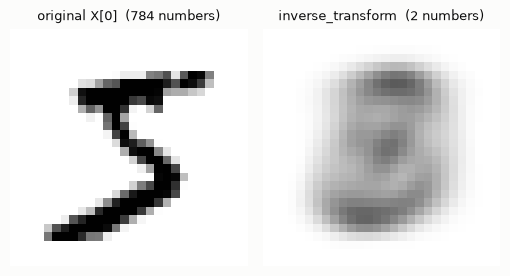

In [17]:
# ---- exactly the snippet above, executed here so the numbers are not hand-copied ----
reloaded = joblib.load(MODEL_PATH)

DEMO_INDEX = 0
digit_raw = X_raw[DEMO_INDEX]                         # uint8, (784,)
digit = digit_raw.astype(np.float64) / 255.0
z_demo = reloaded.transform(digit.reshape(1, -1))

print("demo image      : X[%d], true label = %d" % (DEMO_INDEX, y_all[DEMO_INDEX]))
print("in the 10k subsample used for fitting? ->",
      bool(np.isin(DEMO_INDEX, sub_idx)))
print("input           : shape %s dtype %s range [%.4f, %.4f]"
      % (digit.reshape(1, -1).shape, digit.dtype, digit.min(), digit.max()))
print("\ncompressed vector (shape %s, dtype %s):" % (z_demo.shape, z_demo.dtype))
print("  ", z_demo)
print("\nfull precision (this is the value a peer must reproduce):")
print("   [[%s, %s]]" % (repr(float(z_demo[0, 0])), repr(float(z_demo[0, 1]))))

recon = reloaded.inverse_transform(z_demo).reshape(28, 28)

fig, axes = plt.subplots(1, 2, figsize=(5.2, 2.8))
for ax, img, title in [(axes[0], digit.reshape(28, 28), "original X[%d]  (784 numbers)" % DEMO_INDEX),
                       (axes[1], recon, "inverse_transform  (2 numbers)")]:
    ax.imshow(img, cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(title, fontsize=9, color=INK)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
plt.tight_layout()
plt.show()

In [18]:
# ---- bit-for-bit verification --------------------------------------------------
z_inmemory = pca_model.transform(digit.reshape(1, -1))       # model still in RAM
z_reloaded = reloaded.transform(digit.reshape(1, -1))        # model read back from disk

assert np.array_equal(z_inmemory, z_reloaded), "round-trip through joblib changed the values!"
assert np.array_equal(reloaded.components_, pca_model.components_)
assert np.array_equal(reloaded.mean_, pca_model.mean_)
print("np.array_equal(in-memory, reloaded) ->", np.array_equal(z_inmemory, z_reloaded))

# and the whole subsample, not just one digit
assert np.array_equal(reloaded.transform(X_sub), pca_model.transform(X_sub))
print("all %d embedded points identical      -> True" % SUBSAMPLE_N)

# Footnote: PCA.fit_transform returns U * S straight from the SVD, while transform
# re-projects as (X - mean_) @ components_.T. Algebraically identical, but they take
# different floating-point routes, so they agree only to machine epsilon -- not bitwise.
# The round-trip guarantee above is about transform vs transform, which IS exact.
print("\nfit_transform(X_sub) vs transform(X_sub): bitwise equal ->",
      np.array_equal(EMB["PCA"], pca_model.transform(X_sub)),
      "| max |diff| = %.2e" % np.abs(EMB["PCA"] - pca_model.transform(X_sub)).max())

# the classic mistakes, so the peer can recognise the symptom
wrong_raw = reloaded.transform(digit_raw.astype(np.float64).reshape(1, -1))
wrong_std = reloaded.transform(
    ((digit - digit.mean()) / (digit.std() + 1e-12)).reshape(1, -1))
print("\nWhat a preprocessing mistake looks like:")
print("  correct  (/255.0)      :", np.array2string(z_demo[0], precision=6))
print("  forgot to divide by 255:", np.array2string(wrong_raw[0], precision=6))
print("  per-image standardised :", np.array2string(wrong_std[0], precision=6))

np.array_equal(in-memory, reloaded) -> True


all 10000 embedded points identical      -> True



fit_transform(X_sub) vs transform(X_sub): bitwise equal -> False | max |diff| = 9.55e-14

What a preprocessing mistake looks like:
  correct  (/255.0)      : [0.482861 1.285732]
  forgot to divide by 255: [853.886405 266.27421 ]
  per-image standardised : [2.576605 3.688152]


In [19]:
# ---- models/README.md, generated from the values just computed so it can never drift ----
z0, z1 = float(z_demo[0, 0]), float(z_demo[0, 1])
evr = reloaded.explained_variance_ratio_

L = [
    "# Saved model — MNIST PCA (784 -> 2)",
    "",
    "Artifact for the **Submission** part of the project (README, Chapter V).",
    "Produced by `03_visualizations.ipynb`; see that notebook for why PCA was chosen over",
    "t-SNE / UMAP / LLE (short version: the task demands that *the compressed vector has the",
    "same values*, so the model must be a deterministic parametric map. `TSNE` has no",
    "`transform` at all, `UMAP.transform` runs a stochastic optimisation, and `LLE.transform`",
    "is fragile and drags the whole training set along).",
    "",
    "| | |",
    "|---|---|",
    "| file | `mnist_pca.joblib` (%.1f KB) |" % (os.path.getsize(MODEL_PATH) / 1024),
    "| estimator | `sklearn.decomposition.PCA(n_components=2, svd_solver='full', random_state=%d)` |" % RANDOM_STATE,
    "| fitted on | %d MNIST images (exactly %d per digit) drawn from the 70000 in `data/mnist.npz` |" % (SUBSAMPLE_N, PER_DIGIT),
    "| preprocessing at fit time | `X.astype(np.float64) / 255.0` |",
    "| explained variance ratio | %.6f, %.6f  (sum %.4f) |" % (evr[0], evr[1], evr.sum()),
    "| scikit-learn | %s |" % sklearn.__version__,
    "| numpy | %s |" % np.__version__,
    "| joblib | %s |" % joblib.__version__,
    "| python | %s |" % sys.version.split()[0],
    "",
    "Machine-readable copy of the same facts: `mnist_pca_meta.json`.",
    "",
    "## Preprocessing contract",
    "",
    "`PCA.transform` computes `z = (x - mean_) @ components_.T`, and `mean_` was learnt on",
    "pixels scaled to `[0, 1]`. Feed it anything else and the numbers will not match:",
    "",
    "- **dtype** `np.float64` — cast *before* dividing;",
    "- **scaling** divide by `255.0` and nothing else — no `StandardScaler`, no per-image",
    "  normalisation, no manual mean subtraction (the model carries `mean_` itself);",
    "- **shape** `(n_samples, 784)`, so a single digit needs `.reshape(1, -1)`;",
    "- **output** `(n_samples, 2)` `float64`.",
    "",
    "## How to load and apply",
    "",
    "```python",
    "import joblib, numpy as np",
    "",
    'pca = joblib.load("models/mnist_pca.joblib")          # sklearn PCA, n_components=2',
    "",
    'X = np.load("data/mnist.npz")["X"]                    # (70000, 784) uint8',
    "digit = X[%d].astype(np.float64) / 255.0               # the contract: float64, /255" % DEMO_INDEX,
    "z = pca.transform(digit.reshape(1, -1))               # -> (1, 2)",
    "",
    "print(z)",
    "```",
    "",
    "## Expected result",
    "",
    "Demo image: **`X[%d]`**, the first MNIST training image, a handwritten **%d**." % (DEMO_INDEX, y_all[DEMO_INDEX]),
    "",
    "```",
    "[[%.8f %.8f]]" % (z0, z1),
    "```",
    "",
    "Full double precision (what `np.array_equal` is checked against):",
    "",
    "```python",
    "[[%s, %s]]" % (repr(z0), repr(z1)),
    "```",
    "",
    "Reproduced bit-for-bit in the notebook with",
    "`np.array_equal(pca_in_memory.transform(x), joblib.load(path).transform(x))`.",
    "",
    "If your numbers differ, check the scaling first — these are the two classic mistakes:",
    "",
    "```",
    "correct   (/255.0)        : [%.6f %.6f]" % (z_demo[0, 0], z_demo[0, 1]),
    "forgot to divide by 255   : [%.6f %.6f]" % (wrong_raw[0, 0], wrong_raw[0, 1]),
    "per-image standardised    : [%.6f %.6f]" % (wrong_std[0, 0], wrong_std[0, 1]),
    "```",
    "",
    "## Decompressing back to an image",
    "",
    "```python",
    "recon = pca.inverse_transform(z).reshape(28, 28)      # 2 numbers -> 28 x 28",
    "```",
    "",
    "Two components keep only %.1f %% of the total pixel variance, so the reconstruction is a" % (100 * evr.sum()),
    "blurry average-digit-like blob, not a readable %d. That is expected: 2-D is a" % y_all[DEMO_INDEX],
    "visualisation budget, not a compression budget.",
    "",
]
readme_text = "\n".join(L)
with open("models/README.md", "w") as f:
    f.write(readme_text)

print("wrote models/README.md (%d bytes)\n" % os.path.getsize("models/README.md"))
print(readme_text)

wrote models/README.md (2926 bytes)

# Saved model — MNIST PCA (784 -> 2)

Artifact for the **Submission** part of the project (README, Chapter V).
Produced by `03_visualizations.ipynb`; see that notebook for why PCA was chosen over
t-SNE / UMAP / LLE (short version: the task demands that *the compressed vector has the
same values*, so the model must be a deterministic parametric map. `TSNE` has no
`transform` at all, `UMAP.transform` runs a stochastic optimisation, and `LLE.transform`
is fragile and drags the whole training set along).

| | |
|---|---|
| file | `mnist_pca.joblib` (16.2 KB) |
| estimator | `sklearn.decomposition.PCA(n_components=2, svd_solver='full', random_state=42)` |
| fitted on | 10000 MNIST images (exactly 1000 per digit) drawn from the 70000 in `data/mnist.npz` |
| preprocessing at fit time | `X.astype(np.float64) / 255.0` |
| explained variance ratio | 0.095646, 0.071647  (sum 0.1673) |
| scikit-learn | 1.9.0 |
| numpy | 2.5.2 |
| joblib | 1.5.3 |
| python | 3.1

## Summary**What was done.** MNIST was loaded from `data/mnist.npz`, every image treated as a vector
in $\mathbb{R}^{784}$, scaled by $1/255$, and one **balanced subsample of 10 000 images
(exactly 1 000 per digit, seed 42)** was projected to 2-D by all six required methods — PCA,
SVD, Randomized-SVD, t-SNE, UMAP and LLE — so that fit times and metrics are directly
comparable.

**Task 3.iii — the six projections.** Fit times ranged from **0.57 s** (Randomized-SVD) to
**137 s** (t-SNE); 304 s in total. Step 3 established numerically that

* PCA $\equiv$ `TruncatedSVD` on centred data (principal angles $\sim 10^{-13}$ degrees),
* Randomized-SVD $\equiv$ exact ARPACK SVD for practical purposes (angles $\sim 10^{-3}$
  degrees, coordinates equal to $5.6\times10^{-4}$), with an ablation showing the
  approximation degrading by four orders of magnitude once the power iterations and
  oversampling are removed,
* PCA $\ne$ uncentred SVD (principal angles $85.9^\circ$ and $6.5^\circ$), because the
  first uncentred component is the mean image (cosine $0.9993$) and encodes total ink
  ($|r| = 0.93$) rather than shape.

**Task 3.iv — the metrics.** Six complementary measures were proposed and justified: k-NN
accuracy in 2-D (local, downstream-relevant), silhouette (global compactness, assumes convex
clusters), trustworthiness (label-free neighbourhood preservation against the original
784-D space), plus Davies-Bouldin, Calinski-Harabasz and an intra/inter distance ratio.
Overall ranking by mean rank: **UMAP > t-SNE $\gg$ LLE > PCA $\gg$ SVD $\approx$
Randomized-SVD**. The manifold methods separate the classes far better (k-NN $\approx
0.945$ vs $0.430$ for PCA) because they optimise 20 000 free coordinates rather than a
single plane; the linear methods remain ~100x faster, deterministic and invertible. The
metrics were deliberately chosen to disagree, and the LLE column is the clearest lesson:
3rd on k-NN and trustworthiness but *below PCA* on silhouette, because it preserves local
neighbourhoods inside a collapsed, non-convex core.

**Submission.** The fitted **PCA** — the only kind of model here that is deterministic,
parametric and stateless at apply time — is saved to `models/mnist_pca.joblib`, with
`models/README.md` and `models/mnist_pca_meta.json` recording the preprocessing contract,
the library versions and the exact expected output. Reloading it from disk and transforming
`X[0]` reproduces the documented vector bit-for-bit (`np.array_equal` $\rightarrow$ `True`),
for that digit and for all 10 000 subsample points.

In [20]:
print("notebook wall-clock runtime: %.1f s (%.1f min)"
      % (time.perf_counter() - NB_START, (time.perf_counter() - NB_START) / 60))

notebook wall-clock runtime: 332.8 s (5.5 min)
